In [63]:
import pandas as pd
import copy

from os import listdir, path
from os.path import isfile, join

from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# from tabulate import tabulate
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


from mpl_toolkits.axes_grid1.inset_locator import inset_axes 
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import make_interp_spline

In [2]:
# dataset_list = ['mnist','blog','income','cifar10']
dataset_list = ['aloi','blog','adult','syn','sensorless','covtype','helena','higgs_small']
# dataset_list = ['syn','cifar10']

In [3]:
allFiles=[]
for dataset in dataset_list :
    # mypath = "results/"+ dataset +"/"
    mypath = "results/"+ dataset +"/"
    onlyfiles = [mypath + f for f in listdir(mypath) if isfile(join(mypath, f))]
    onlyfiles = [f for f in onlyfiles if f[-3:] == "csv"]
    allFiles.extend(onlyfiles)
# allFiles


In [4]:
allFiles[0]

'results/aloi/Client-4-contrastive-50e-6fl-0.25mc-targeted_at-random_dt-0.8rl-aloi.csv'

In [5]:
for i, item in enumerate(allFiles):
    dt = pd.read_csv(item)
    dt["client"] = int(item.split("-")[1])
    # dt["type"] = item.split("-")[-1].split(".")[0]
    dt["epoch"] = int(item.split("-")[3][:-1])
    dt["fl"] = int(item.split("-")[4][:-2])
    dt["mc"] = float(item.split("-")[5][:-2])
    dt["at"] = str(item.split("-")[6][:-3])
    dt["dt"] = str(item.split("-")[7][:-3])
    dt["db"] = str(item.split("-")[-1][:-4])
    dt["f1"] = dt.test_acc.apply(lambda x : eval(x)[-2])
    dt["accuracy"] = dt.test_acc.apply(lambda x : eval(x)[0])
    
    if i ==0 : db = dt
    else : db = pd.concat([db,dt])
# db = pd.merge(db[db.type == 'original'], db[db.type == 'contrastive'], on=["client","model"])
db = db[['client',	'epoch',	'fl',	'mc',	'at',	'dt',	'db','accuracy','f1']]
db = db[db.epoch == 50]
db.head()

,client,epoch,fl,mc,at,dt,db,accuracy,f1
0,4,50,6,0.25,targeted,random,aloi,0.413686,0.375177
0,3,50,6,0.25,targeted,trimmed_mean,aloi,0.325879,0.298428
0,5,50,6,0.50,model_replacement,multi_krum,aloi,0.640779,0.586748
0,1,50,6,0.00,scale,random,aloi,0.381279,0.344122
0,1,50,6,0.25,targeted,trimmed_mean,aloi,0.312677,0.280887


In [67]:
# db[db.mc==0.0]

In [7]:
# db['combined'] = db[[  'mc', 'rl']].apply(
#     lambda x: '_'.join(x.astype(str)), axis=1
# )
# idx = [x+ '_' +item+'_'+str(n) for n in range(6) for item in db['at'].unique() for x in db.sort_values(['mc','rl'])['combined'].unique()]
# idx = pd.DataFrame(idx, columns=['idx'])
# idx.head()

In [201]:
attackType=['scale','model_replacement','gradient_ascent','targeted']
defense_type=["multi_krum", "geometric_median", "foolsgold", "trimmed_mean", "momentum", "random","robust"]

malClient=[0.25,0.5,0.75]
malClient=[0.0,0.25,0.5,0.75]
randomLevel=[1,0.25,0.5,0.75]
idx_list=[]
for dt in dataset_list:
    for n in range(6):
        idx_list.append(['_'.join([dt,'scale',str(0.0),str(1.0),str(n)]),dt,'scale',0.0,1.0,n])
        for mc in malClient:
            for dl in defense_type:
                for at in attackType:
                    idx_list.append(['_'.join([dt,at,str(mc),str(dl),str(n)]),dt,at,mc,dl,n])

idx_all = pd.DataFrame(idx_list, columns=['idx','db','at','mc','dt','client'])
idx_all.tail()
# print(idx_list)

,idx,db,at,mc,dt,client
5419,higgs_small_targeted_0.75_random_5,higgs_small,targeted,0.75,random,5
5420,higgs_small_scale_0.75_robust_5,higgs_small,scale,0.75,robust,5
5421,higgs_small_model_replacement_0.75_robust_5,higgs_small,model_replacement,0.75,robust,5
5422,higgs_small_gradient_ascent_0.75_robust_5,higgs_small,gradient_ascent,0.75,robust,5
5423,higgs_small_targeted_0.75_robust_5,higgs_small,targeted,0.75,robust,5


In [202]:
db['combined'] = db[[  'db','at','mc', 'dt','client']].apply(
    lambda x: '_'.join(x.astype(str)), axis=1
)
db.tail()

,client,epoch,fl,mc,at,dt,db,accuracy,f1,combined,nl
0,3,50,6,0.25,model_replacement,foolsgold,higgs_small,0.281587,0.367932,higgs_small_model_replacement_0.25_foolsgold_3,False
0,2,50,6,0.75,model_replacement,multi_krum,higgs_small,0.531642,0.496214,higgs_small_model_replacement_0.75_multi_krum_2,False
0,0,50,6,0.25,targeted,random,higgs_small,0.513336,0.445319,higgs_small_targeted_0.25_random_0,False
0,1,50,6,0.75,scale,foolsgold,higgs_small,0.281587,0.367932,higgs_small_scale_0.75_foolsgold_1,False
0,3,50,6,0.25,gradient_ascent,geometric_median,higgs_small,0.533289,0.516773,higgs_small_gradient_ascent_0.25_geometric_med...,False


In [10]:
dbx=idx_all.merge(db,left_on='idx', 
                          right_on='combined',
                          how='left')
dbx = dbx[['idx','client_x', 'mc_x', 'at_x', 'dt_x', 'db_x', 'accuracy','f1',]]
dbx.columns = ['idx','client', 'mc', 'at', 'dt', 'db', 'accuracy','f1',]
dbx.mc = dbx.mc.astype(float)
# dbx.rl = dbx.rl.astype(float)
dbx.f1 = dbx.f1.astype(float)
dbx.f1 = dbx.f1.apply(lambda x : x if x>0 else np.nan)
dbx['nl'] = dbx.f1.isna() # number or fail

dbx['nnl'] = dbx.f1.notna() # number of success
# dbx[dbx.db=='aloi']['at'].unique()
# dbx.tail()

## Explore

In [11]:
def printDb(dataset,dbn):
# dataset, dbn = 'aloi', dbx
    print('\subsection{ Dataset used:', dataset.replace('_','-') ,'}')
    # print(dbn['at'].unique())
    dbx = dbn[dbn.db==str(dataset)]
    dbx = dbx.drop(
        dbx.query("mc == '0.0' and at!= 'scale'").index
    )
    
    dbNl = dbx[['mc','dt','at','nl']].pivot_table(
                    values='nl', 
                    index=['mc','dt',],
                    columns='at',
                    aggfunc='sum').reset_index()
    print('\subsubsection{ Fail Matrix','}')
    # print(dbNl)
    print((dbNl[['mc','scale', 'model_replacement', 'gradient_ascent', 'targeted']].groupby('mc').sum()/42).to_latex(float_format="%.2f").replace('_','-'))
    print((dbNl[['dt','scale', 'model_replacement', 'gradient_ascent', 'targeted']].groupby('dt').sum() / 42).to_latex(float_format="%.2f").replace('_','-'))
    # dbNnl = 
    dbx.f1 = dbx.f1.apply(lambda x : x if x>0 else np.nan)
    dbF1 = dbx[['mc','dt','at','f1']].pivot_table(
                    values='f1', 
                    index=['mc','dt',],
                    columns='at',
                    aggfunc='mean').reset_index()
    print('\subsubsection{ F1 Matrix','}')
    # print(dbF1.columns[:])
    cols = list(dbF1.columns[2:])
    print((dbF1[['mc']+ cols ].groupby('mc').mean()).to_latex(float_format="%.2f").replace('_','-'))
    print((dbF1[['dt'] + cols].groupby('dt').mean()).to_latex(float_format="%.2f").replace('_','-'))
    # print('***End of Matrixs***')


# printDb('helena',dbx)

In [12]:
# for item in dataset_list:
#     printDb(item,dbx)


In [13]:
db['at'].unique()

array(['targeted', 'model_replacement', 'scale', 'gradient_ascent',
       'direction'], dtype=object)

In [14]:
# attack = 'scale'
def printAttack(attack):
    print(f'\\subsection{{Attack Type:{attack} }}'.replace('_','-'))
    dbAt = dbx[dbx['at']==attack]
    # dbAt.f1 = dbAt.f1.apply(lambda x : x if x>0 else np.nan)
    # dbAt['nl'] = dbAt.f1.isna()
    # dbAt['nnl'] = dbAt.f1.notna()
    
    print('\subsubsection{ASR Matrix','}')
    dbAt_ = dbAt.query("mc != 0.0")
    dbAt_
    dbAt_ = dbAt_[['mc','dt','db','nl']].pivot_table(
                        values='nl', 
                        index=['mc','dt',],
                        columns='db',
                        aggfunc='sum').reset_index()
    
    # print(dbAt_.to_latex(index=False,formatters={"name": str.upper},
    #               float_format="{:.1f}".format,))
    cols = list(dbAt_.columns[2:])
    print('\\begin{table}[]')
    print(f'\caption{{ASR matrix of {attack} based on the rate of random client selection applied to CFL.',
    f'The cvt is covertype, hln is helena, sns is sensorless, and syn is synthetic dataset.}}')
    print((dbAt_[['mc']+cols].groupby('mc').sum()/42).to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,).replace('_','-'))
    print('\end{table}')
    
    print('\\begin{table}[]')
    print(f'\caption{{ASR matrix of {attack} based on the defense type applied to CFL.',
    f'The cvt is covertype, hln is helena, sns is sensorless, and syn is synthetic dataset.}}')
    
    print((dbAt_[['dt']+cols].groupby('dt').sum() / 18).to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,).replace('_','-'))
    print('\end{table}')
    
    print('\subsubsection{F1 Matrix','}')
    
    dbAt_ = dbAt[['mc','dt','db','f1']].pivot_table(
                        values='f1', 
                        index=['mc','dt',],
                        columns='db',
                        aggfunc='mean').reset_index()
    # print(dbAt_.to_latex(index=False,formatters={"name": str.upper},
    #               float_format="{:.1f}".format,))
    print('\\begin{table}[]')
    print(f'\caption{{F1 matrix of {attack} based on the rate of random client selection applied to CFL.',
    f'The cvt is covertype, hln is helena, sns is sensorless, and syn is synthetic dataset.}}')
    print(dbAt_[['mc']+cols].groupby('mc').mean().to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,).replace('_','-'))
    print('\end{table}')
    
    print('\\begin{table}[]')
    print(f'\caption{{F1 matrix of {attack} based on the rate of defense type applied to CFL.',
    f'The cvt is covertype, hln is helena, sns is sensorless, and syn is synthetic dataset.}}')
    print(dbAt_[['dt']+cols].groupby('dt').mean().to_latex(index=True,formatters={"name": str.upper},
                  float_format="{:.1f}".format,).replace('_','-'))
    print('\end{table}')
    

# printAttack('model_replacement')

In [15]:
# for item in db['at'].unique():
#     printAttack(item)

In [16]:
dbR = dbx[dbx['at']!= 'targeted'][['dt','nl','db']].pivot_table(
                        values='nl', 
                        index=['dt',],
                        columns='db',
                        aggfunc='sum').reset_index().set_index('dt')
dbR

db,adult,aloi,blog,covtype,helena,higgs_small,sensorless,syn
dt,,,,,,,,
1.0,6,6,6,6,6,6,6,6
foolsgold,0,54,6,0,0,0,54,18
geometric_median,30,24,24,24,24,24,24,24
momentum,24,18,18,30,18,30,18,18
multi_krum,30,36,30,36,30,36,30,30
random,30,36,30,36,30,36,30,30
robust,30,36,30,36,30,36,30,30
trimmed_mean,30,36,24,36,30,36,18,18


In [17]:
dbR_ = dbx[dbx['at']!= 'targeted'][['dt','mc','db']].pivot_table(
                        values='mc', 
                        index=['dt',],
                        columns='db',
                        aggfunc='count').reset_index().set_index('dt')
dbR_

db,adult,aloi,blog,covtype,helena,higgs_small,sensorless,syn
dt,,,,,,,,
1.0,6,6,6,6,6,6,6,6
foolsgold,54,54,54,54,54,54,54,54
geometric_median,54,54,54,54,54,54,54,54
momentum,54,54,54,54,54,54,54,54
multi_krum,54,54,54,54,54,54,54,54
random,54,54,54,54,54,54,54,54
robust,54,54,54,54,54,54,54,54
trimmed_mean,54,54,54,54,54,54,54,54


In [18]:
dbF1 = dbx[dbx['at']!= 'targeted'][['dt','f1','db']].pivot_table(
                        values='f1', 
                        index=['dt',],
                        columns='db',
                        aggfunc='mean').reset_index().set_index('dt')
dbF1

db,adult,aloi,blog,covtype,helena,higgs_small,sensorless,syn
dt,,,,,,,,
foolsgold,0.656442,NaN,0.643001,0.319536,0.009383,0.367932,NaN,0.017812
geometric_median,0.752266,0.446852,0.720212,0.473062,0.136243,0.483346,0.314196,0.575030
momentum,0.752892,0.467557,0.719637,0.474445,0.121438,0.480274,0.231809,0.546642
multi_krum,0.749312,0.445529,0.720994,0.473012,0.132258,0.483444,0.289188,0.602511
random,0.751829,0.420429,0.719923,0.473700,0.129884,0.480277,0.299645,0.601579
robust,0.750886,0.436617,0.720302,0.473457,0.132602,0.481056,0.294693,0.602893
trimmed_mean,0.749071,0.354734,0.719865,0.472509,0.136068,0.482166,0.287314,0.609994


In [19]:
db_m = dbR /dbR_
db_m = db_m.iloc[1:] 
# dbF1 = dbF1.fillna(dbF1.mean())

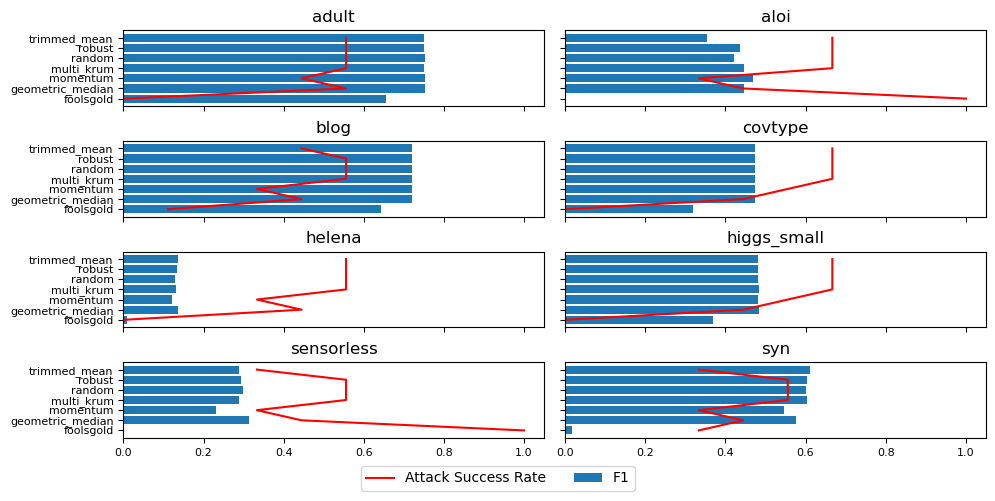

In [20]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 8          # Default font size for text
plt.rcParams['axes.titlesize'] = 12    # Font size for titles
plt.rcParams['axes.labelsize'] = 10      # Font size for x and y labels
plt.rcParams['xtick.labelsize'] = 8     # Font size for x-axis ticks
plt.rcParams['ytick.labelsize'] = 8     # Font size for y-axis ticks
plt.rcParams['legend.fontsize'] = 10 


fig, axs = plt.subplots(4, 2, sharex=True,figsize=(10, 5), sharey=True)
for i,ax in enumerate(axs.flat):
    X_, Y_ = dbF1.index,dbF1[dbF1.columns[i]]
    ax.barh(X_,Y_, label='F1')
    # X,Y = db_m.index, db_m[dbF1.columns[i]]
    X,Y = db_m[dbF1.columns[i]], db_m.index
    ax.plot(X,Y,label='Attack Success Rate', color='red')
    ax.set_title( dbF1.columns[i])
handles, labels = [], []
for i,ax in enumerate(axs.flat):
    for handle, label in zip(*ax.get_legend_handles_labels()):
        handles.append(handle)
        labels.append(label)
        
handles, labels = handles[-2:], labels[-2:]
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), 
           ncol=4, frameon=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)

plt.savefig('conclusion.png', dpi=300, bbox_inches='tight')

In [209]:
db['f1old'] = db.f1
db.f1 = db.f1.apply(lambda x : x if x>0 else np.nan)
db['nl'] = db.f1.isna()

In [210]:
final=db[['mc', 'at', 'dt', 'f1', 'nl',]]
final.nl.unique()

array([False,  True])

In [73]:
# final[final.mc==0.25][['at', 'dt', 'f1']].groupby(['at','dt']).mean().reset_index().pivot(index='at', columns='dt', values='f1')

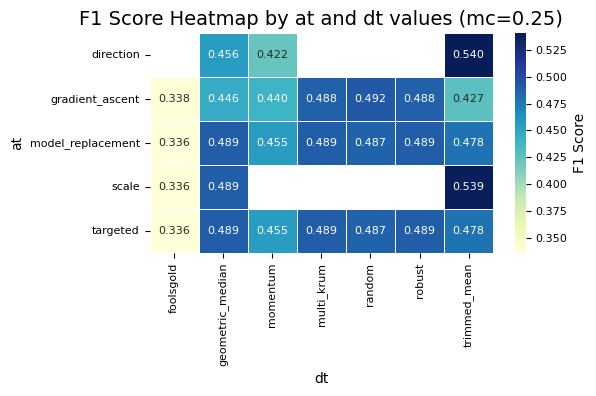

In [211]:
pivoted_df = final[final.mc==0.25][['at', 'dt', 'f1']].groupby(['at','dt']).mean().reset_index().pivot(index='at', columns='dt', values='f1')

# Now create the heatmap
plt.figure(figsize=(6, 4))

# Create the heatmap
sns.heatmap(pivoted_df, 
            annot=True,           # Show values in cells
            fmt='.3f',            # Format as 3 decimal places
            cmap='YlGnBu',        # Yellow-Green-Blue color map (good for F1 scores)
            cbar_kws={'label': 'F1 Score'},
            linewidths=0.5)

plt.title('F1 Score Heatmap by at and dt values (mc=0.25)', fontsize=14)
plt.tight_layout()
plt.show()


In [228]:
df=final
mc_val=0.25
df[df.mc == mc_val][['at', 'dt', 'f1']].groupby(['at','dt']).mean().reset_index().pivot(
            index='at', columns='dt', values='f1').fillna(0)

dt,foolsgold,geometric_median,momentum,multi_krum,random,robust,trimmed_mean
at,,,,,,,
direction,0.000000,0.455984,0.422418,0.000000,0.000000,0.000000,0.540434
gradient_ascent,0.338323,0.445666,0.439612,0.487775,0.492344,0.488015,0.427246
model_replacement,0.335684,0.488523,0.455359,0.489339,0.486601,0.489117,0.478425
scale,0.335684,0.488695,0.000000,0.000000,0.000000,0.000000,0.539059
targeted,0.335684,0.488523,0.455359,0.489339,0.486601,0.489117,0.478425


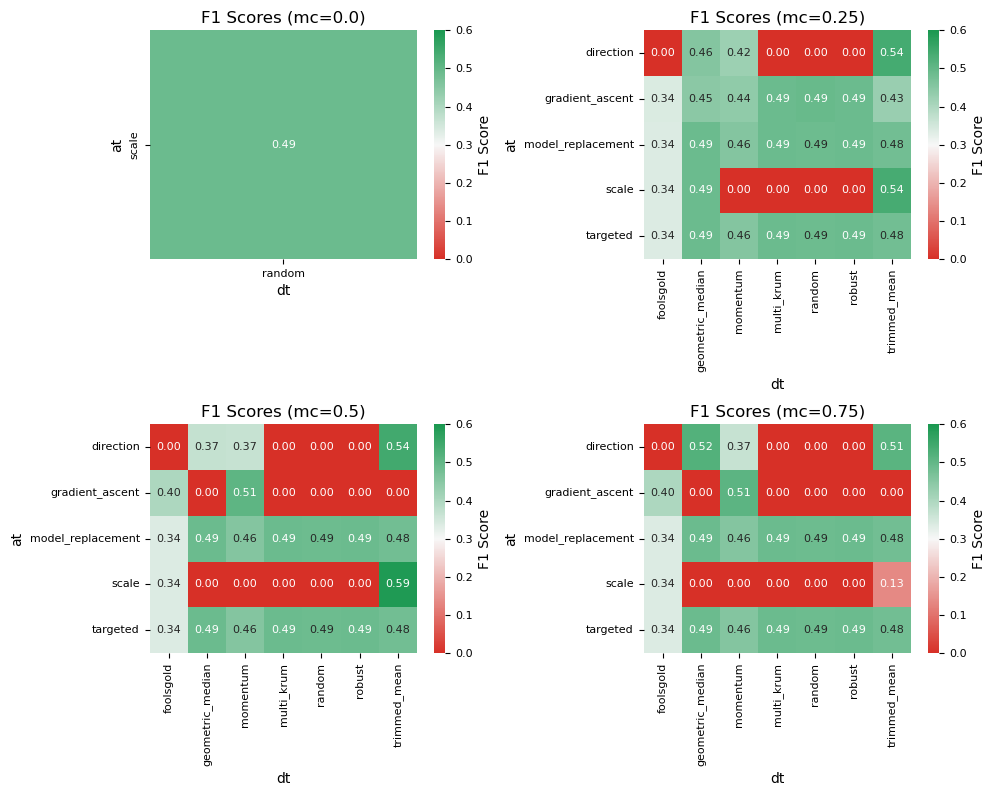

In [246]:
def plot_facet_heatmaps(df):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()
    cmap = LinearSegmentedColormap.from_list('custom_div', 
                                           ['#d73027', '#f7f7f7', '#1a9850'], N=256)
    
    for i, mc_val in enumerate([0.  , 0.25, 0.5 , 0.75]):
        # Filter and pivot data for this mc value
        pivoted = df[df.mc == mc_val][['at', 'dt', 'f1']].groupby(['at','dt']).mean().reset_index().pivot(
            index='at', columns='dt', values='f1').fillna(0)
        
        # Create heatmap on the corresponding subplot
        ax = axes[i]
        sns.heatmap(pivoted, annot=True, fmt='.2f', cmap=cmap, 
                   cbar_kws={'label': 'F1 Score'}, ax=ax, vmin=0.0, vmax=0.6)
        ax.set_title(f'F1 Scores (mc={mc_val})', fontsize=12)
    
    plt.tight_layout()
   
    plt.savefig('f1Final.png', dpi=300, bbox_inches='tight')
    plt.show()
plot_facet_heatmaps(final)

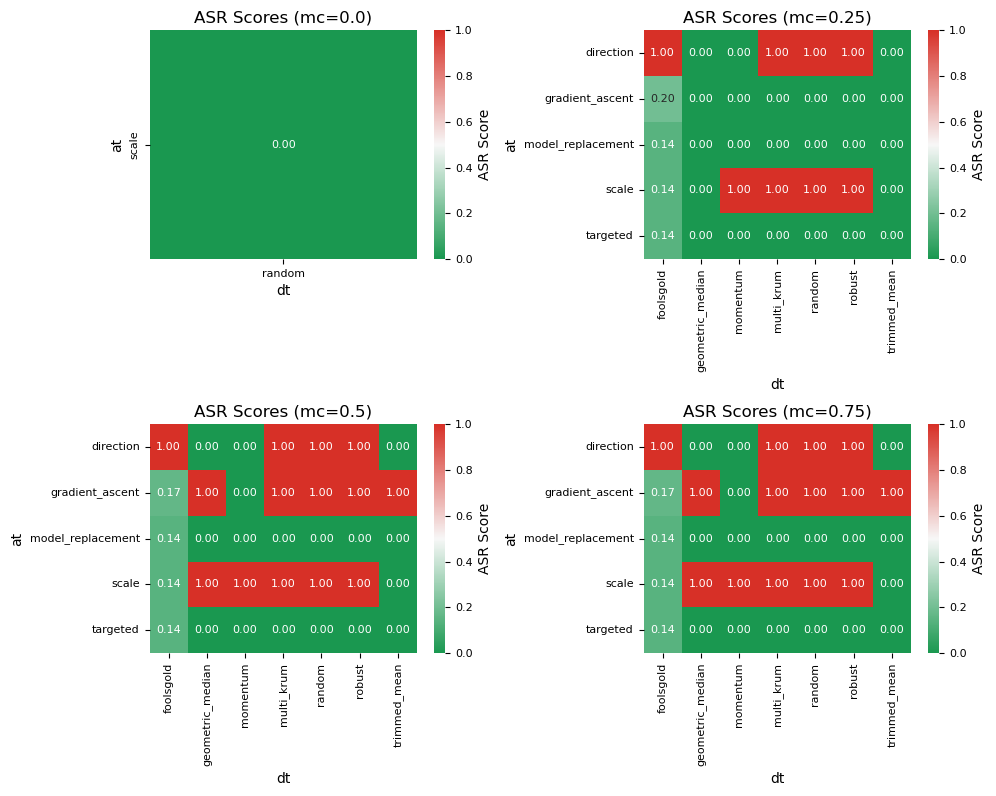

In [244]:
def plot_facet_heatmaps(df):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()
    cmap = LinearSegmentedColormap.from_list('custom_div', 
                                           ['#1a9850', '#f7f7f7', '#d73027'], N=256)
    
    for i, mc_val in enumerate([0.  , 0.25, 0.5 , 0.75]):
        # Filter and pivot data for this mc value
        pivoted = df[df.mc == mc_val][['at', 'dt', 'nl']].groupby(['at','dt']).mean().reset_index().pivot(
            index='at', columns='dt', values='nl').fillna(1)
        
        # Create heatmap on the corresponding subplot
        ax = axes[i]
        sns.heatmap(pivoted, annot=True, fmt='.2f', cmap=cmap, 
                   cbar_kws={'label': 'ASR Score'}, ax=ax, vmin=0.0, vmax=1)
        ax.set_title(f'ASR Scores (mc={mc_val})', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('asrFinal.png', dpi=300, bbox_inches='tight')
    plt.show()
plot_facet_heatmaps(final)

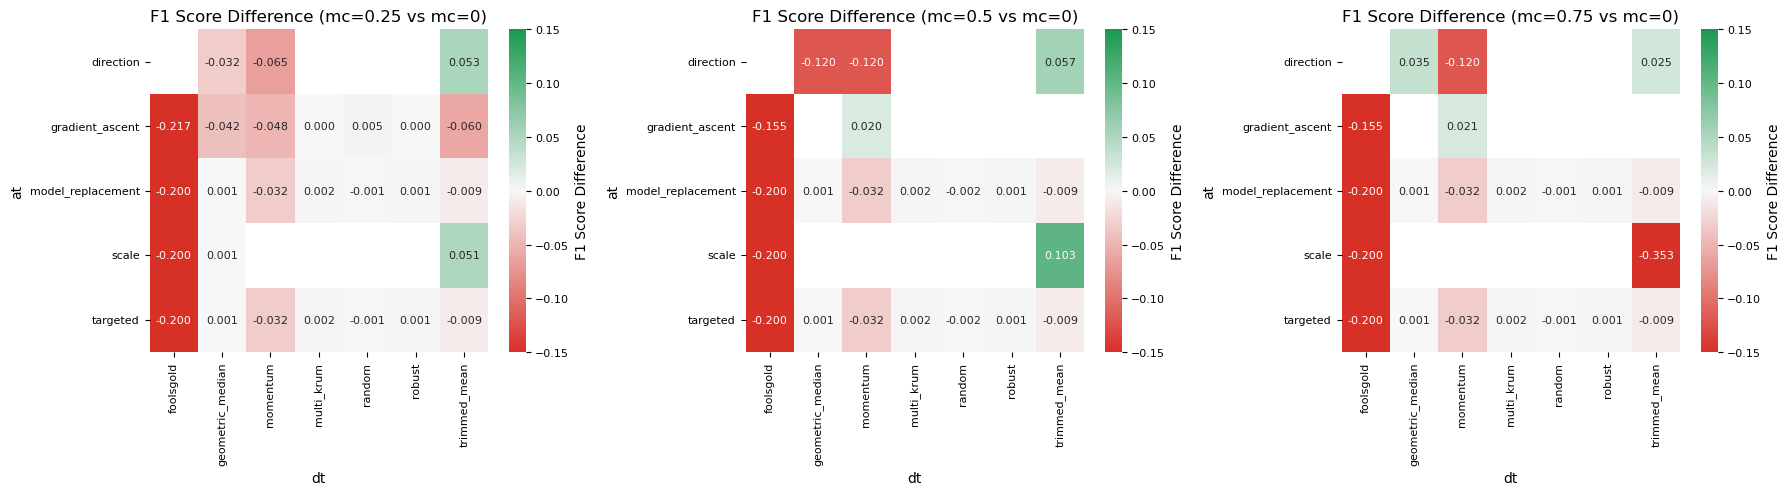

In [99]:
def plot_difference_heatmaps(df):
    # Get baseline (mc=0) pivoted data
    baseline = df[df.mc == 0][['at', 'dt', 'f1']].groupby(['at','dt']).mean().reset_index().pivot(
        index='at', columns='dt', values='f1').values[0][0]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Custom diverging colormap for differences
    cmap = LinearSegmentedColormap.from_list('custom_div', 
                                           ['#d73027', '#f7f7f7', '#1a9850'], N=256)
    
    for i, mc_val in enumerate([0.25, 0.5, 0.75]):
        # Get data for this mc value
        current = df[df.mc == mc_val][['at', 'dt', 'f1']].groupby(['at','dt']).mean().reset_index().pivot(
            index='at', columns='dt', values='f1')
        
        # Calculate difference from baseline
        diff = (current - baseline)
        # print(baseline, current)
        
        # Plot difference heatmap
        ax = axes[i]
        sns.heatmap(diff, annot=True, fmt='.3f', cmap=cmap, 
                   center=0, ax=ax, vmin=-0.15, vmax=0.15,
                   cbar_kws={'label': 'F1 Score Difference'})
        ax.set_title(f'F1 Score Difference (mc={mc_val} vs mc=0)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
plot_difference_heatmaps(final)

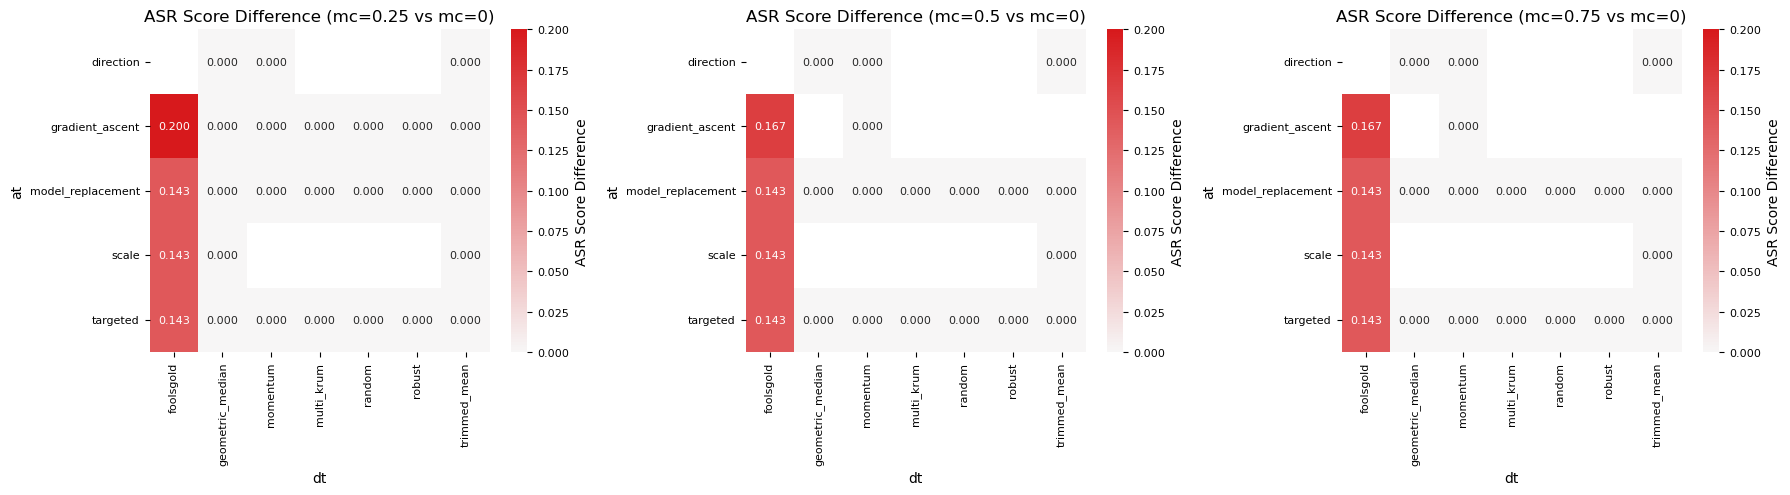

In [225]:
def plot_difference_heatmaps(df):
    # Get baseline (mc=0) pivoted data
    baseline = df[df.mc == 0][['at', 'dt', 'nl']].groupby(['at','dt']).mean().reset_index().pivot(
        index='at', columns='dt', values='nl').values[0][0]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Custom diverging colormap for differences
    cmap = LinearSegmentedColormap.from_list('red_green_soft', ['#1a9622', '#f7f7f7','#d7191c' ], N=256)

    
    for i, mc_val in enumerate([0.25, 0.5, 0.75]):
        # Get data for this mc value
        current = df[df.mc == mc_val][['at', 'dt', 'nl']].groupby(['at','dt']).mean().reset_index().pivot(
            index='at', columns='dt', values='nl')
        
        # Calculate difference from baseline
        diff = (current - baseline)
        # print(baseline, current)
        
        # Plot difference heatmap
        ax = axes[i]
        sns.heatmap(diff, annot=True, fmt='.3f', cmap=cmap, 
                   center=0, ax=ax, vmin=0.0, vmax=0.2,
                   cbar_kws={'label': 'ASR Score Difference'})
        ax.set_title(f'ASR Score Difference (mc={mc_val} vs mc=0)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
plot_difference_heatmaps(final)

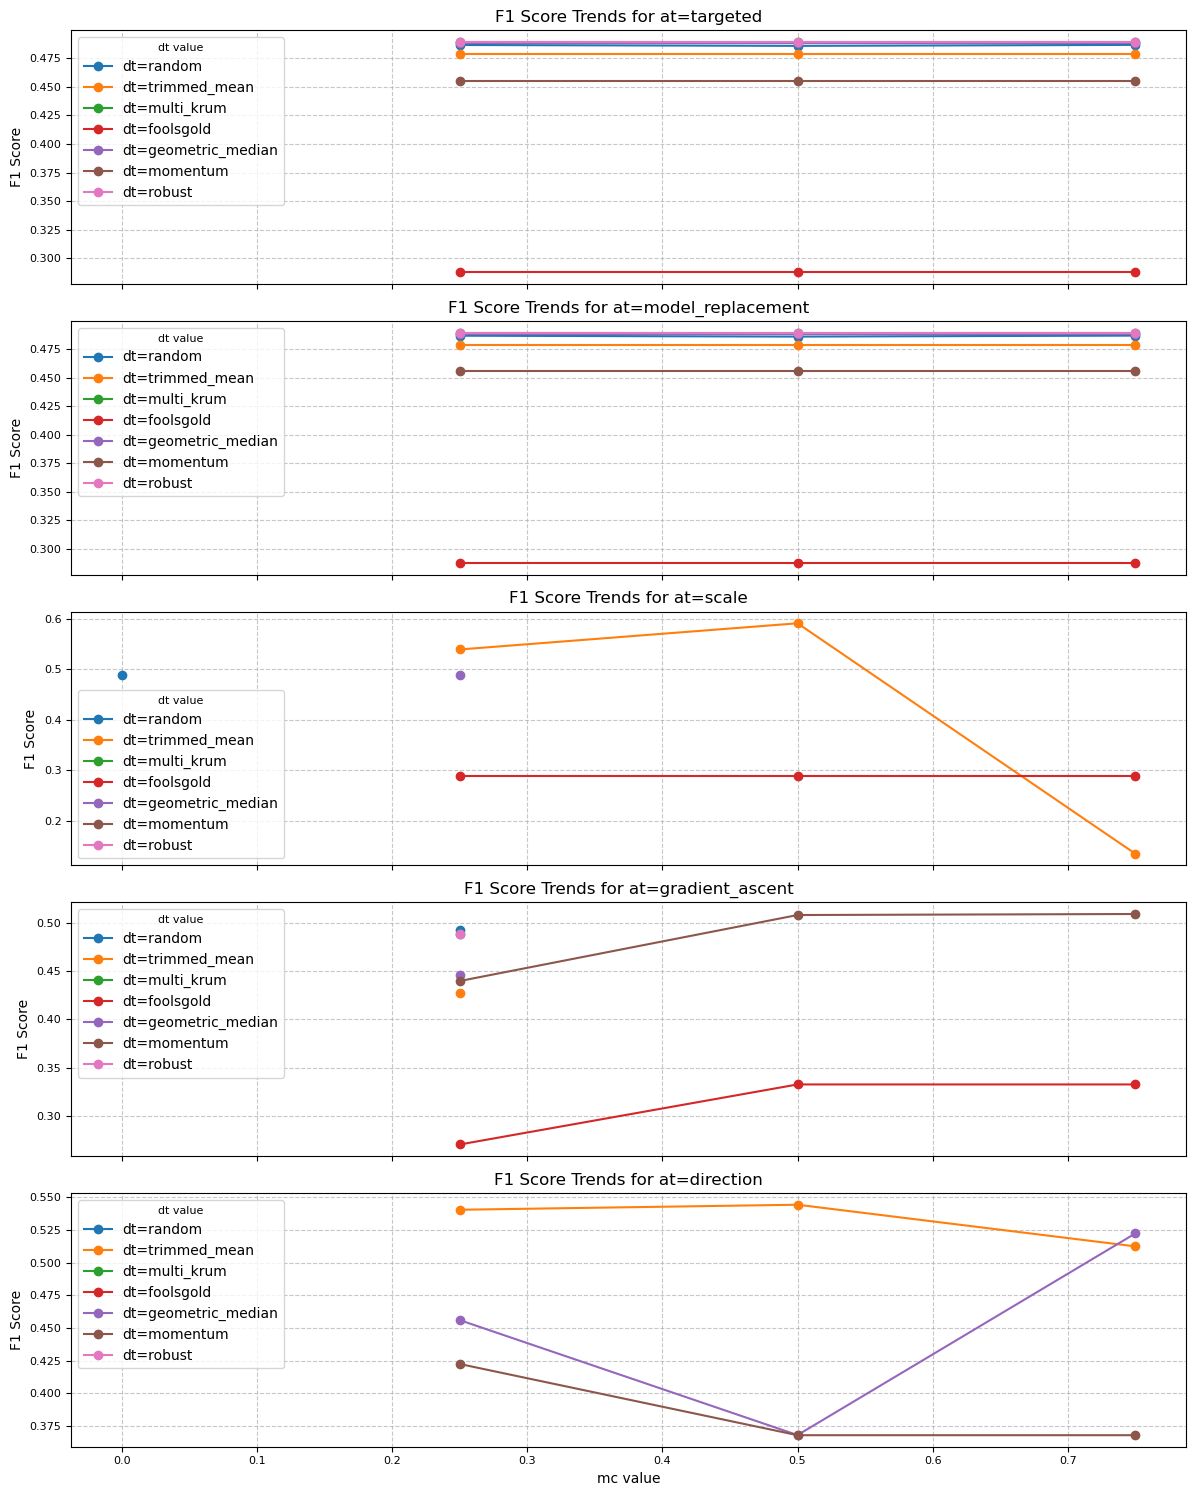

In [109]:
def plot_line_trends(df):
    # Group by all three variables
    grouped = df.groupby(['mc', 'at', 'dt']).mean().reset_index()
    at_values = df['at'].unique()
    dt_values = df['dt'].unique()
    # Create a figure with subplots for each at value
    fig, axes = plt.subplots(len(at_values), 1, figsize=(12, 15), sharex=True)
    
    for i, at_val in enumerate(at_values):
        ax = axes[i]
        at_data = grouped[grouped['at'] == at_val]
        
        # Plot lines for each dt value
        for dt_val in dt_values:
            dt_data = at_data[at_data.dt == dt_val]
            ax.plot(dt_data['mc'], dt_data['f1'], marker='o', label=f'dt={dt_val}')
        
        ax.set_title(f'F1 Score Trends for at={at_val}')
        ax.set_ylabel('F1 Score')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(title='dt value')
    
    axes[-1].set_xlabel('mc value')
    plt.tight_layout()
    plt.show()
plot_line_trends(final)

/var/folders/md/17gxb5p94d5_f_nm_06qhsj40000gn/T/ipykernel_4897/2783585643.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


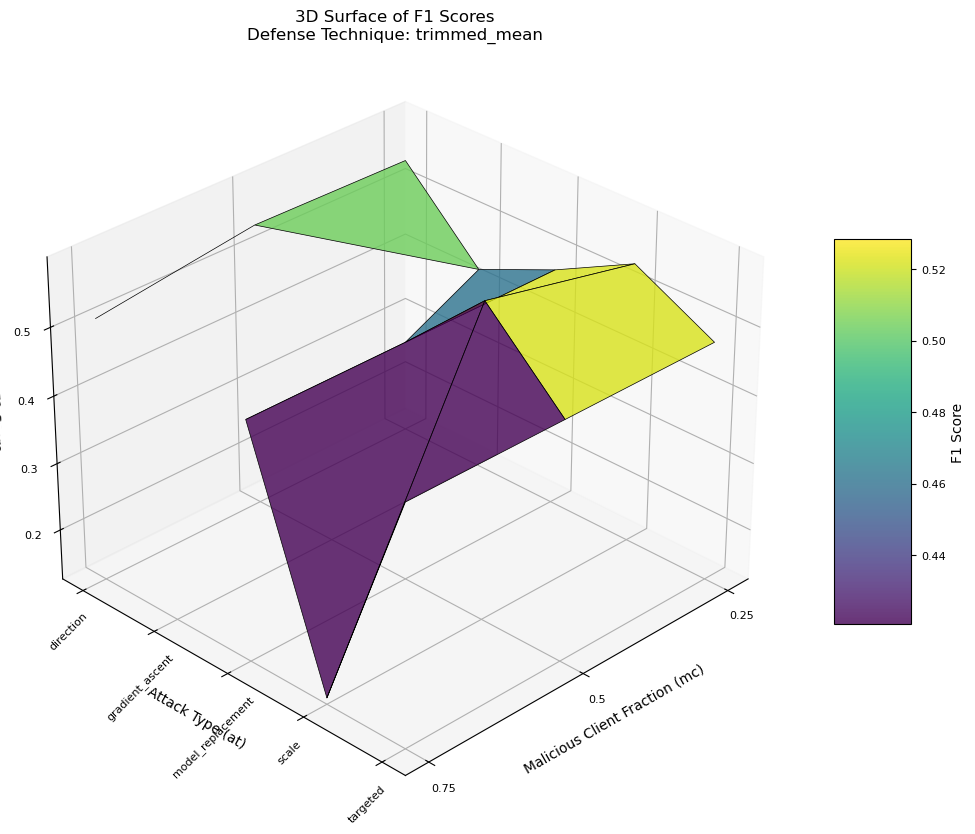

In [120]:
def plot_3d_surface(df, defense_technique='trimmed_mean'):
    """
    Create a 3D surface plot showing how F1 scores vary with attack type and malicious client fraction
    for a specific defense technique.
    
    Args:
        df: DataFrame with the data
        defense_technique: The defense technique to visualize
    """
    # Filter for the specific defense technique
    filtered = df[df.dt == defense_technique]
    
    # Create pivot table with mc and at as indices
    pivoted = filtered.pivot_table(index='mc', columns='at', values='f1')
    
    # For categorical x/y variables in 3D plots, we need to convert to numeric positions
    x_pos = np.arange(len(pivoted.index))
    y_pos = np.arange(len(pivoted.columns))
    x_mesh, y_mesh = np.meshgrid(x_pos, y_pos)
    
    # Create 3D plot
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the surface
    surf = ax.plot_surface(x_mesh, y_mesh, pivoted.T.values, 
                          cmap='viridis', edgecolor='k', lw=0.5, alpha=0.8)
    
    # Set labels with actual categorical values
    ax.set_xlabel('Malicious Client Fraction (mc)')
    ax.set_ylabel('Attack Type (at)')
    ax.set_zlabel('F1 Score')
    ax.set_title(f'3D Surface of F1 Scores\nDefense Technique: {defense_technique}')
    
    # Set tick labels to the actual categorical values
    ax.set_xticks(x_pos)
    ax.set_xticklabels(pivoted.index)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(pivoted.columns, rotation=45)
    
    # Add a color bar
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='F1 Score')
    
    # Improve the viewing angle
    ax.view_init(elev=30, azim=45)
    
    plt.tight_layout()
    plt.show()
    
    # return fig
plot_3d_surface(final)

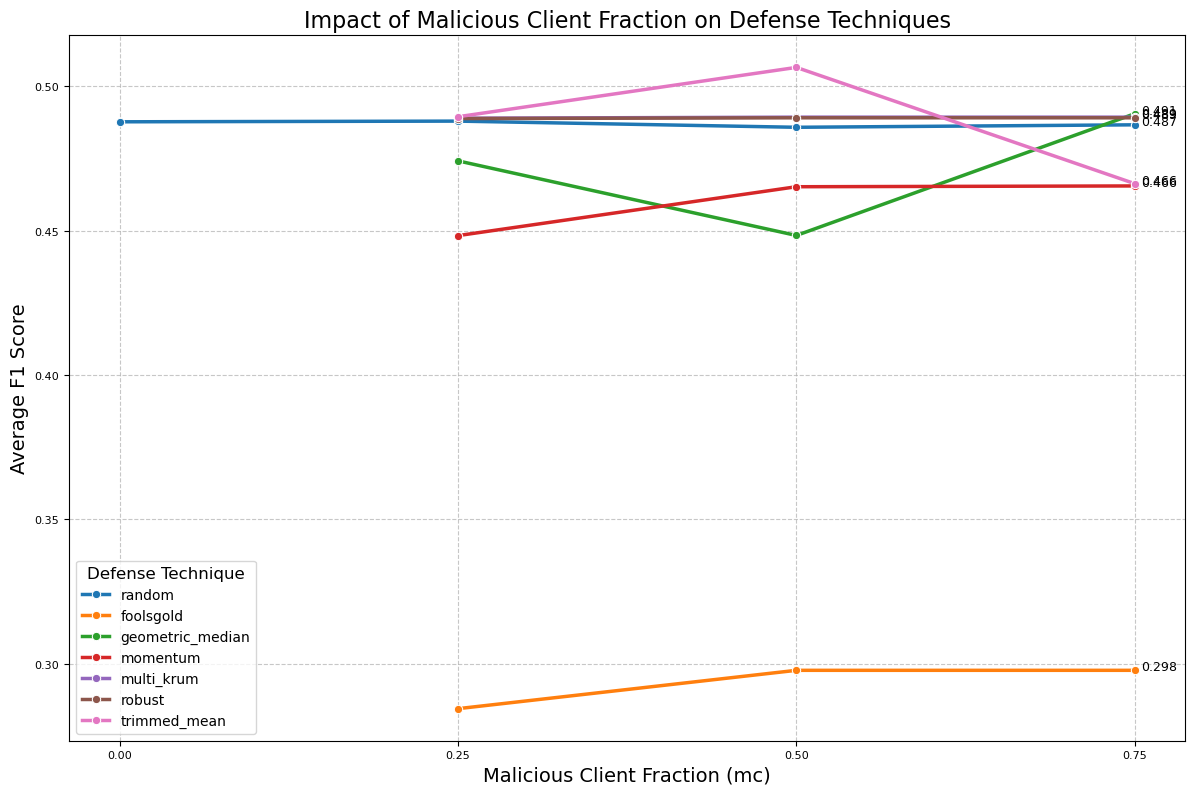

In [124]:
def plot_defense_mc_trends(df=final):
    """
    Create line plots showing how F1 scores change with mc for each defense technique,
    averaged across all attack types.
    """
    mc_values = df.mc.unique()
    dt_values = df['dt'].unique()
    
    plt.figure(figsize=(12, 8))
    
    # Group by mc and defense technique, averaging across all attack types
    avg_by_mc_dt = df.groupby(['mc', 'dt'])['f1'].mean().reset_index()
    
    # Plot a line for each defense technique
    sns.lineplot(data=avg_by_mc_dt, x='mc', y='f1', hue='dt', marker='o', linewidth=2.5)
    
    plt.title('Impact of Malicious Client Fraction on Defense Techniques', fontsize=16)
    plt.xlabel('Malicious Client Fraction (mc)', fontsize=14)
    plt.ylabel('Average F1 Score', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(mc_values)
    plt.legend(title='Defense Technique', title_fontsize=12, fontsize=10)
    
    # Add text annotations for key points
    for dt in dt_values:
        dt_data = avg_by_mc_dt[avg_by_mc_dt.dt == dt]
        for i, row in dt_data.iterrows():
            if row['mc'] == 0.75:  # Annotate the final point
                plt.annotate(f"{row['f1']:.3f}", 
                            xy=(row['mc'], row['f1']),
                            xytext=(5, 0),
                            textcoords='offset points',
                            fontsize=9)
    
    plt.tight_layout()
    plt.show()
plot_defense_mc_trends()

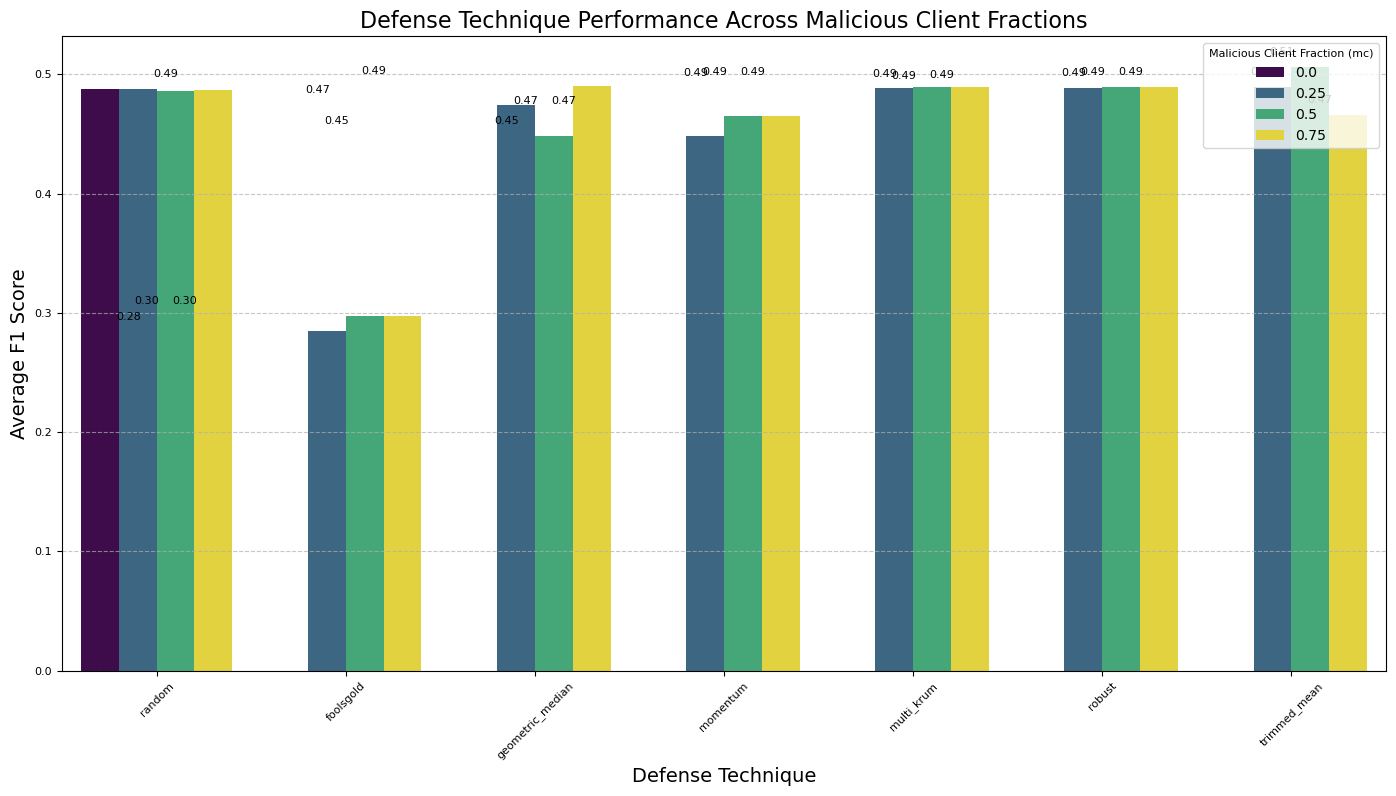

In [128]:
# 3. Bar chart showing defense techniques at different mc values
def plot_defense_mc_bars(df=final):
    """
    Create grouped bar chart showing F1 scores for each defense technique
    at different mc values.
    """
    mc_values = df.mc.unique()
    dt_values = df['dt'].unique()
    # Calculate average F1 for each defense technique at each mc value
    avg_by_mc_dt = df.groupby(['mc', 'dt'])['f1'].mean().reset_index()
    
    plt.figure(figsize=(14, 8))
    
    # Create grouped bar chart
    sns.barplot(data=avg_by_mc_dt, x='dt', y='f1', hue='mc', palette='viridis')
    
    plt.title('Defense Technique Performance Across Malicious Client Fractions', fontsize=16)
    plt.xlabel('Defense Technique', fontsize=14)
    plt.ylabel('Average F1 Score', fontsize=14)
    plt.legend(title='Malicious Client Fraction (mc)')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    
    # Add text annotations for the bars
    for i, mc in enumerate(mc_values):
        mc_data = avg_by_mc_dt[avg_by_mc_dt.mc == mc]
        for j, (_, row) in enumerate(mc_data.iterrows()):
            plt.text(j + (i - 1.5) * 0.1, row['f1'] + 0.01, 
                    f"{row['f1']:.2f}", ha='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
plot_defense_mc_bars()

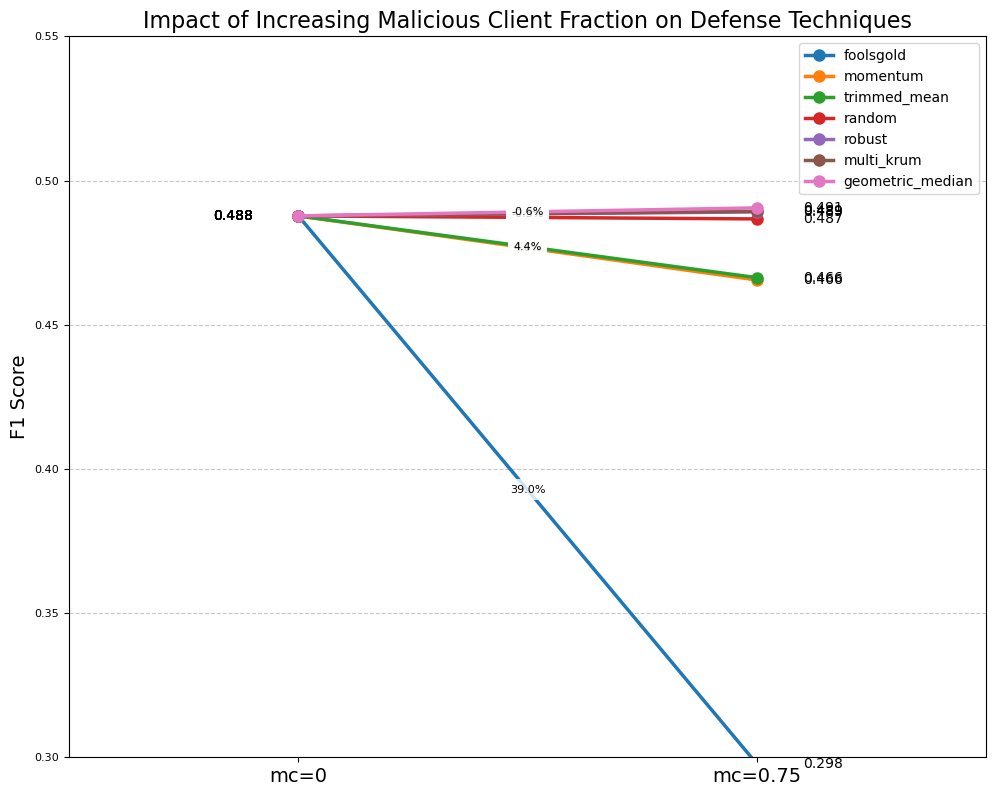

In [161]:
def plot_defense_slope_chart(df=final):
    """
    Create a slope chart showing how each defense technique's F1 score
    changes from mc=0 to mc=0.75.
    """
    # Get data for mc=0 and mc=0.75
    mc0_data = df[df.mc == 0].groupby('dt')['f1'].mean().reset_index()
    mc75_data = df[df.mc == 0.75].groupby('dt')['f1'].mean().reset_index()
    
    # Merge the data
    slope_data = pd.merge(mc75_data, mc0_data, on='dt', suffixes=('_mc75', '_mc0'), how='left')
    slope_data.f1_mc0 = mc0_data.values[0][1]
    
    # Sort by the drop in F1 score
    slope_data['drop'] = slope_data['f1_mc0'] - slope_data['f1_mc75']
    slope_data = slope_data.sort_values('drop', ascending=False)
    
    # Create the slope chart
    plt.figure(figsize=(10, 8))
    
    # Plot lines connecting mc=0 and mc=0.75 for each defense technique
    for i, row in slope_data.iterrows():
        plt.plot([1, 2], [row['f1_mc0'], row['f1_mc75']], '-o', 
                linewidth=2.5, markersize=8, 
                label=row['dt'])
        
        # Add labels
        plt.text(0.9, row['f1_mc0'], f"{row['f1_mc0']:.3f}", 
                ha='right', va='center', fontsize=10)
        plt.text(2.1, row['f1_mc75'], f"{row['f1_mc75']:.3f}", 
                ha='left', va='center', fontsize=10)
        
        # Add defense technique labels
        # plt.text(0.8, row['f1_mc0'], row['dt'], 
        #         ha='right', va='center', fontsize=12)
    
    # Set up the axes
    plt.xlim(0.5, 2.5)
    plt.ylim(0.3, 0.55)
    plt.legend()
    plt.xticks([1, 2], ['mc=0', 'mc=0.75'], fontsize=14)
    plt.ylabel('F1 Score', fontsize=14)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.title('Impact of Increasing Malicious Client Fraction on Defense Techniques', fontsize=16)
    
    # Add drop percentage annotations
    for i, row in slope_data.iterrows():
        drop_pct = (row['drop'] / row['f1_mc0']) * 100
        plt.text(1.5, (row['f1_mc0'] + row['f1_mc75'])/2, 
                f"{drop_pct:.1f}%", ha='center', va='center', 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    plt.tight_layout()
    plt.show()
plot_defense_slope_chart()

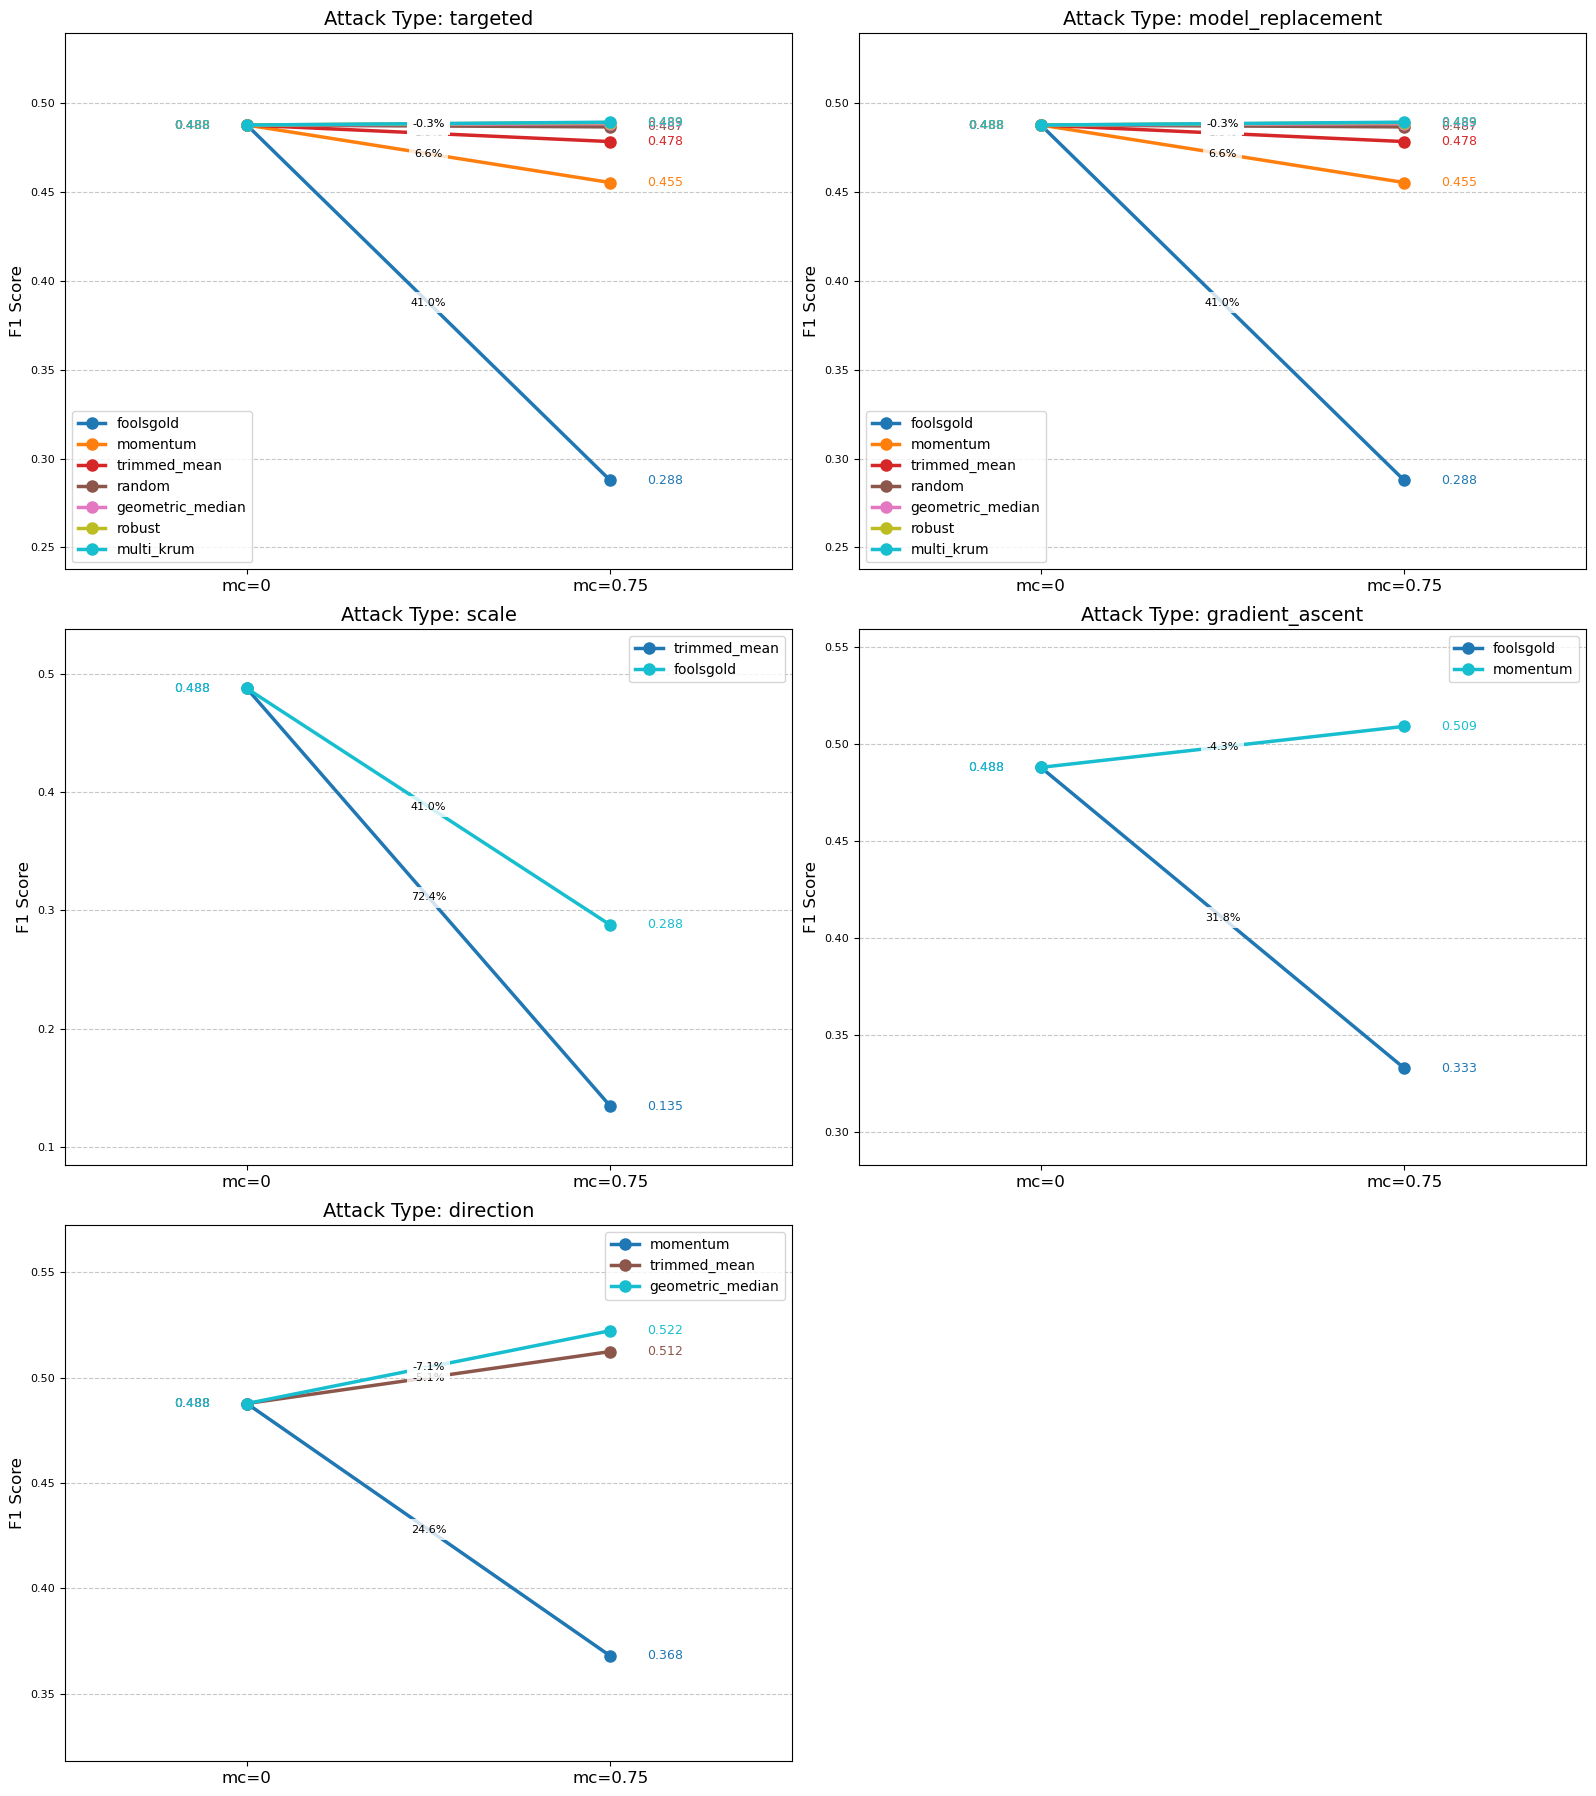

In [173]:
def plot_defense_slope_by_attack(df=final):
    """
    Create slope charts for each attack type in separate subplots.
    """
    attack_types = df['at'].unique()
    num_attacks = len(attack_types)
    
    # Calculate grid dimensions
    if num_attacks <= 3:
        rows, cols = 1, num_attacks
    else:
        rows = (num_attacks + 1) // 2
        cols = 2
    
    fig = plt.figure(figsize=(cols*8, rows*6))
    mc0_data = df[df.mc == 0].groupby('dt')['f1'].mean().reset_index()
    
    for i, at in enumerate(attack_types):
        ax = fig.add_subplot(rows, cols, i+1)
        plt.sca(ax)
        
        # Filter data for this attack type
        filtered_df = df[df['at'] == at]
        
        # Get data for mc=0 and mc=0.75
        # mc0_data = filtered_df[filtered_df.mc == 0].groupby('dt')['f1'].mean().reset_index()
        mc75_data = filtered_df[filtered_df.mc == 0.75].groupby('dt')['f1'].mean().reset_index()
        
        # Merge the data
        slope_data = pd.merge(mc75_data, mc0_data, on='dt', suffixes=('_mc75', '_mc0'), how='left')
        slope_data.f1_mc0 = mc0_data.values[0][1]
        
        # Sort by the drop in F1 score
        slope_data['drop'] = slope_data['f1_mc0'] - slope_data['f1_mc75']
        slope_data = slope_data.sort_values('drop', ascending=False)
        
        # Plot lines connecting mc=0 and mc=0.75 for each defense technique
        colors = plt.cm.tab10(np.linspace(0, 1, len(slope_data)))
        
        for j, (_, row) in enumerate(slope_data.iterrows()):
            plt.plot([1, 2], [row['f1_mc0'], row['f1_mc75']], '-o',
                    linewidth=2.5, markersize=8,
                    color=colors[j],
                    label=row['dt'])
            
            # Add labels
            plt.text(0.9, row['f1_mc0'], f"{row['f1_mc0']:.3f}",
                    ha='right', va='center', fontsize=9,
                    color=colors[j])
            plt.text(2.1, row['f1_mc75'], f"{row['f1_mc75']:.3f}",
                    ha='left', va='center', fontsize=9,
                    color=colors[j])
        
        # Set up the axes
        plt.xlim(0.5, 2.5)
        
        # Dynamically set y-limits based on data range
        y_min = min(slope_data['f1_mc75'].min(), slope_data['f1_mc0'].min()) - 0.05
        y_max = max(slope_data['f1_mc75'].max(), slope_data['f1_mc0'].max()) + 0.05
        plt.ylim(max(0, y_min), min(1, y_max))
        
        plt.legend(loc='best')
        plt.xticks([1, 2], ['mc=0', 'mc=0.75'], fontsize=12)
        plt.ylabel('F1 Score', fontsize=12)
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        plt.title(f'Attack Type: {at}', fontsize=14)
        
        # Add drop percentage annotations
        for j, row in slope_data.iterrows():
            drop_pct = (row['drop'] / row['f1_mc0']) * 100
            plt.text(1.5, (row['f1_mc0'] + row['f1_mc75'])/2,
                    f"{drop_pct:.1f}%", ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    plt.tight_layout()
    plt.show()

# Run both functions
# 
plot_defense_slope_by_attack()  # Breakdown by attack type